
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

make a random variable
Uniform distribution = all values have equal chance between0 and 1
size 1000 rows with 2 columns



In [60]:
import numpy as np

rng = np.random.default_rng(seed=42)
n=1000
x = rng.uniform(0, 1, size=(1000, 2))
print(x[:5])
# Noise vector: 1000 samples from N(0,1)
y = rng.normal(loc=0, scale=1, size=(n))
# Target variable y = 3*x1 + 5*x2 + 3=intercept + epsilon
y = 3 * x[:, 0] + 5 * x[:, 1] + 3 + y
print(y[:5])

# Add column of ones for intercept
X = np.c_[np.ones(n), x]


[[0.77395605 0.43887844]
 [0.85859792 0.69736803]
 [0.09417735 0.97562235]
 [0.7611397  0.78606431]
 [0.12811363 0.45038594]]
[6.49173143 9.97069675 6.95794722 8.9273745  5.05021895]


Imagine you’re standing on a mountain in thick fog.
You want to reach the lowest point in the valley.
You can’t see the whole landscape.
But you can feel the slope under your feet.
So you take small steps downhill.
That’s gradient descent.
- The mountain = the cost function (how wrong your model is)
- The lowest point = the best parameters (θ₀, θ₁, θ₂)
- The slope = the gradient
- The step size = the learning rate η

The gradient descent:
Where:
- X is your design matrix (with the column of ones)
- y is your target vector
- η  is the learning rate
- n is the number of samples



In [61]:
            #θ₀, θ₁, θ₂= 3, 3, 5,intercept, coefficient of x1, coefficient of x2
# Initialize θ
theta = np.zeros(3)
# Learning rate
eta = 0.1

epochs = 500# Number of iterations for gradient descent/reading data 500 times

theta_history = []

for epoch in range(epochs):
    gradient = (1/n) * X.T @ (X @ theta - y)
    theta = theta - eta * gradient
    
    if epoch % 5 == 0:   # every 5th epoch
        theta_history.append(theta.copy())

Full Gradient Descent (Task 1):

This part of the homework is teaching how gradient descent behaves depending on the learning rate (η).
(a): η = 0.1, every 5th epoch, up to 500
The picture says:
- compute θ after epoch 1
- compute θ after epoch 6
- compute θ after epoch 11
- …
- compute θ after epoch 496
Why?
Because you want to plot how θ changes over time.
This shows you how gradient descent moves toward the correct values.

Part (b): η = 0.01, every 20th epoch, up to 5000
Same idea, but:
- smaller learning rate
- more epochs
- save θ less often (every 20 epochs)
Why?
Because with a smaller η, gradient descent moves slower, so you need more epochs to see progress.

Experiment with larger and smaller η
This is the “play and learn” part.
Try:
- η = 1
- η = 0.5
- η = 0.001
- η = 0.0001


eta = 1.0, final theta = [3.14888868 2.78105957 4.96382314]
eta = 0.5, final theta = [3.14888954 2.78105887 4.96382224]
eta = 0.1, final theta = [3.23828137 2.72324317 4.85417571]
eta = 0.01, final theta = [4.27716014 2.4603623  3.16755815]
eta = 0.001, final theta = [2.44919798 1.32106978 1.41141032]
Last theta (eta=0.1): [3.23828137 2.72324317 4.85417571]


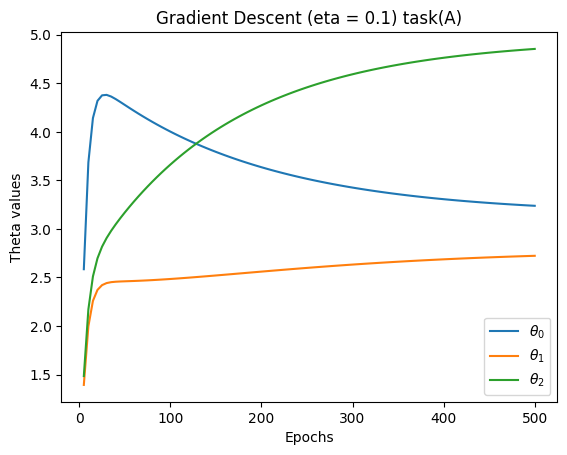

Final theta (eta=0.01): [3.2389267  2.72294666 4.85326406]


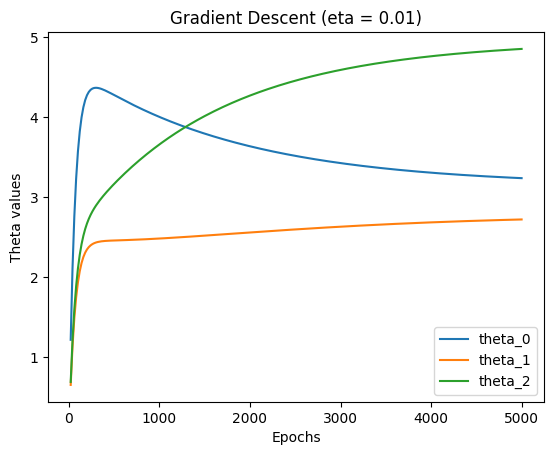

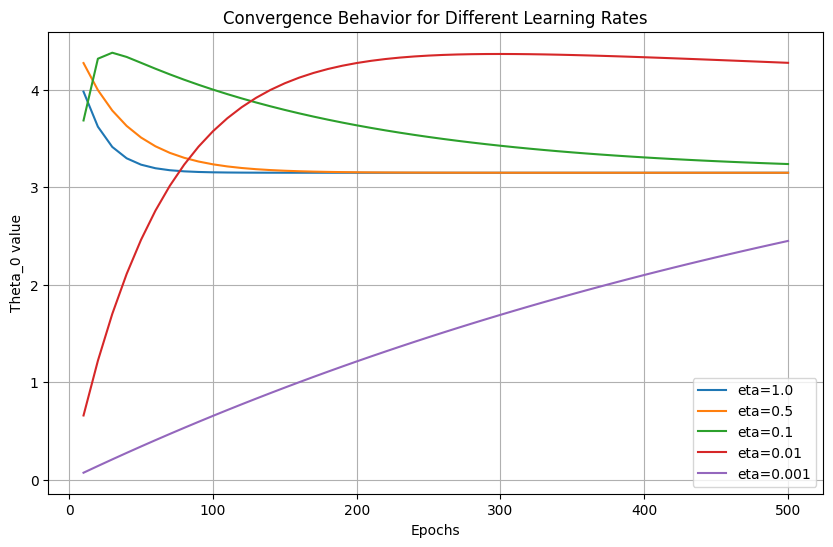

In [62]:
def gradient_descent(X, y, eta, epochs, log_every):
    n, d = X.shape
    theta = np.zeros(d)
    theta_history = []
    epoch_history = []

    for epoch in range(1, epochs + 1):
        y_pred = X @ theta                 # predictions
        error = y_pred - y                 # residuals /how wrong the model is
        gradient = (1/n) * X.T @ error     # gradient of MSE / direction of steepest increase in error
        theta = theta - eta * gradient #- step downhill (reduce error)    # update step

        if epoch % log_every == 0:# only store θ every k epochs (for plotting)
            theta_history.append(theta.copy())
            epoch_history.append(epoch)

    return np.array(epoch_history), np.array(theta_history)


etas = [1.0, 0.5, 0.1, 0.01, 0.001]

for eta in etas:
    epochs = 500
    log_every = 10

    epochs_hist, theta_hist = gradient_descent(X, y, eta, epochs, log_every)
    print(f"eta = {eta}, final theta = {theta_hist[-1]}")


#A) This is very close to true value (3, 3, 5) and converges quickly.Last theta (eta=0.1): [3.23828137 2.72324317 4.85417571]
eta_a = 0.1
epochs_a = 500
log_every_a = 5

epochs_a_hist, theta_a_hist = gradient_descent(X, y, eta_a, epochs_a, log_every_a)

print("Last theta (eta=0.1):", theta_a_hist[-1])
import matplotlib.pyplot as plt

plt.plot(epochs_a_hist, theta_a_hist[:, 0], label=r'$\theta_0$')
plt.plot(epochs_a_hist, theta_a_hist[:, 1], label=r'$\theta_1$')
plt.plot(epochs_a_hist, theta_a_hist[:, 2], label=r'$\theta_2$')
plt.xlabel("Epochs")
plt.ylabel("Theta values")
plt.title("Gradient Descent (eta = 0.1) task(A)")
plt.legend()
plt.show()

#B) This is also close to the true value but requires more epochs to converge. - Converges much slower
# Needs thousands of epochs Very smooth and stable η = 0.01 is safe but slow

eta_b = 0.01
epochs_b = 5000
log_every_b = 20

epochs_b_hist, theta_b_hist = gradient_descent(X, y, eta_b, epochs_b, log_every_b)
print("Final theta (eta=0.01):", theta_b_hist[-1])
plt.plot(epochs_b_hist, theta_b_hist[:, 0], label="theta_0")
plt.plot(epochs_b_hist, theta_b_hist[:, 1], label="theta_1")
plt.plot(epochs_b_hist, theta_b_hist[:, 2], label="theta_2")
plt.xlabel("Epochs")
plt.ylabel("Theta values")
plt.title("Gradient Descent (eta = 0.01)")
plt.legend()
plt.show()


#c exprimen larg and smaller learning rates


etas = [1.0, 0.5, 0.1, 0.01, 0.001]

plt.figure(figsize=(10,6))

for eta in etas:
    epochs = 500
    log_every = 10
    epochs_hist, theta_hist = gradient_descent(X, y, eta, epochs, log_every)
    plt.plot(epochs_hist, theta_hist[:, 0], label=f"eta={eta}")

plt.xlabel("Epochs")
plt.ylabel("Theta_0 value")
plt.title("Convergence Behavior for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()





## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)

&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.

<details>

<summary>Answer</summary>

a) 

<img src="../data/grad_desc_converg.png" height="200"/>

b) 

<img src="../data/grad_desc_converg_001.png" height="200"/>

</details>

---

What is SGD in everyday language?
Imagine you’re trying to learn how heavy a bag is.
Gradient Descent (Task 1):
You lift all 1000 items in the bag at once → heavy but accurate.
Stochastic Gradient Descent (SGD):
You lift ONE random item at a time → fast but noisy.
That’s the whole idea.
 
 Why does SGD behave differently?
Because:
- It uses one random data point per update
- So the updates are noisy, jumpy, zig‑zaggy
- But it moves much faster
- And sometimes reaches the solution quicker

What is Mini‑Batch Gradient Descent?
It’s a mix between:
- Gradient Descent (uses ALL data → slow but smooth)
- SGD (uses ONE point → fast but noisy)
Mini‑batch uses a small group of points each time, like:



[3.13375252 2.81883544 4.70490429]


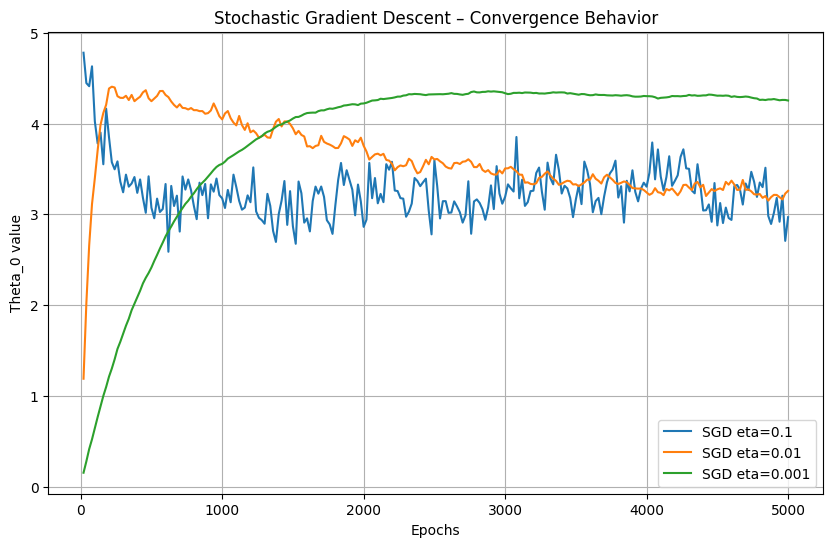

batch=1, final theta=[3.15510735 2.78123127 4.95958781]
batch=10, final theta=[3.13746904 2.77545653 4.95772809]
batch=50, final theta=[3.15225832 2.775996   4.95695533]
batch=100, final theta=[3.23916528 2.72310593 4.85344408]
batch=500, final theta=[4.00376328 2.48466856 3.66042423]


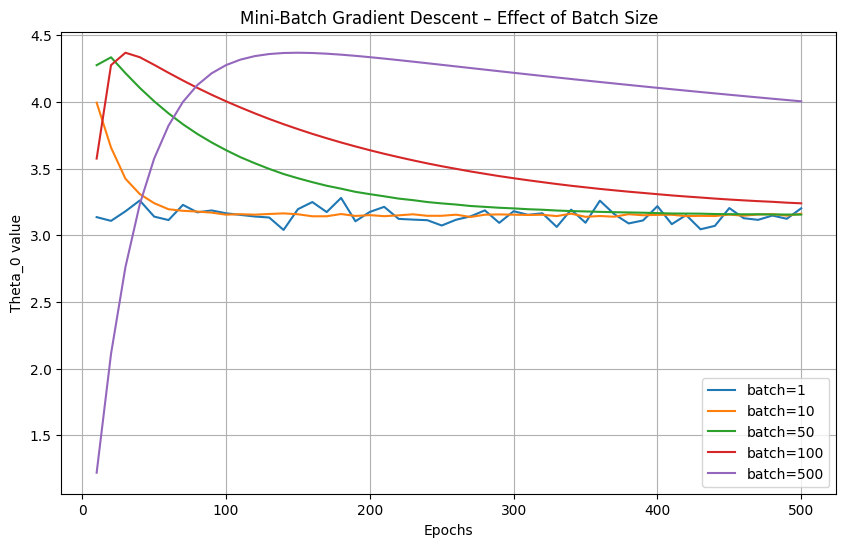

In [63]:
#sgd
def stochastic_gradient_descent(X, y, eta, epochs, log_every):
    n, d = X.shape
    theta = np.zeros(d)
    theta_history = []
    epoch_history = []

    for epoch in range(1, epochs + 1):
        # pick a random index
        i = np.random.randint(0, n)

        # compute prediction for ONE point
        xi = X[i]
        yi = y[i]

        # gradient for one point
        error = (xi @ theta) - yi
        gradient = xi * error

        # update
        theta = theta - eta * gradient

        if epoch % log_every == 0:
            theta_history.append(theta.copy())
            epoch_history.append(epoch)

    return np.array(epoch_history), np.array(theta_history)
epochs_sgd, theta_sgd = stochastic_gradient_descent(X, y, eta=0.01, epochs=5000, log_every=20)
print(theta_sgd[-1])

# --- PLOT FOR STOCHASTIC GRADIENT DESCENT ---

etas = [0.1, 0.01, 0.001]   # try a few learning rates

plt.figure(figsize=(10,6))

for eta in etas:
    epochs_sgd, theta_sgd = stochastic_gradient_descent(
        X, y, eta=eta, epochs=5000, log_every=20
    )
    plt.plot(epochs_sgd, theta_sgd[:, 0], label=f"SGD eta={eta}")

plt.xlabel("Epochs")
plt.ylabel("Theta_0 value")
plt.title("Stochastic Gradient Descent – Convergence Behavior")
plt.legend()
plt.grid(True)
plt.show()

#mini patch gradient descent
def mini_batch_gradient_descent(X, y, eta, epochs, batch_size, log_every):
    n, d = X.shape
    theta = np.zeros(d)
    theta_history = []
    epoch_history = []

    for epoch in range(1, epochs + 1):
        # shuffle the data
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # process mini-batches
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            # compute gradient for the batch
            y_pred = X_batch @ theta
            error = y_pred - y_batch
            gradient = (1 / len(X_batch)) * (X_batch.T @ error)

            # update
            theta = theta - eta * gradient

        if epoch % log_every == 0:
            theta_history.append(theta.copy())
            epoch_history.append(epoch)

    return np.array(epoch_history), np.array(theta_history)

for batch in [1, 10, 50, 100, 500]:
    epochs_mb, theta_mb = mini_batch_gradient_descent(
        X, y, eta=0.01, epochs=500, batch_size=batch, log_every=10
    )
    print(f"batch={batch}, final theta={theta_mb[-1]}")

# --- PLOT FOR MINI-BATCH GRADIENT DESCENT ---

plt.figure(figsize=(10,6))
batch_sizes = [1, 10, 50, 100, 500]   # 1 = SGD, 1000 = full GD
for batch in batch_sizes:
    epochs_mb, theta_mb = mini_batch_gradient_descent(
        X, y, eta=0.01, epochs=500, batch_size=batch, log_every=10
    )
    plt.plot(epochs_mb, theta_mb[:, 0], label=f"batch={batch}")

plt.xlabel("Epochs")
plt.ylabel("Theta_0 value")
plt.title("Mini-Batch Gradient Descent – Effect of Batch Size")
plt.legend()
plt.grid(True)
plt.show()

## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---